In [1]:
from google.colab import drive
import os

# Google Drive'ı bağlayın
drive.mount('/content/drive')


Mounted at /content/drive


# **resnet50**


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: ResNet50, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: ResNet50, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.517241358757019
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.48383620381355286
Model: ResNet50, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: ResNet50, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.48383620381355286
Model: ResNet50, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: ResNet50, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.48383620381355286
Model: ResNet50, Activat

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


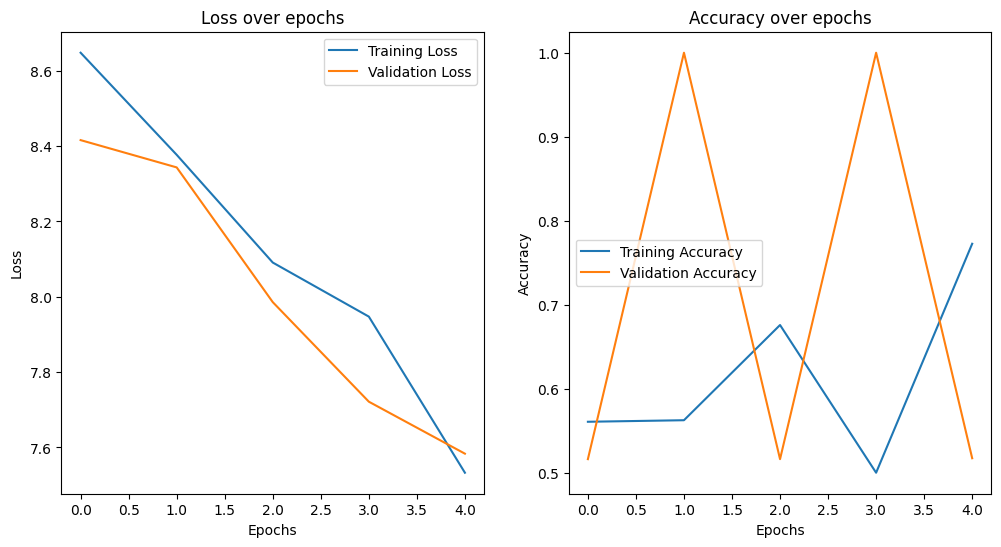

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-30:]:  # Fine-tune the last 30 layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'ResNet50',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: ResNet50, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model ResNet50, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# **Vgg16**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG16, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.600215494632721
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG16, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.607758641242981
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG16, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.6530172228813171
Model: VGG16, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG16, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.642241358757019
Model: VGG16, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 

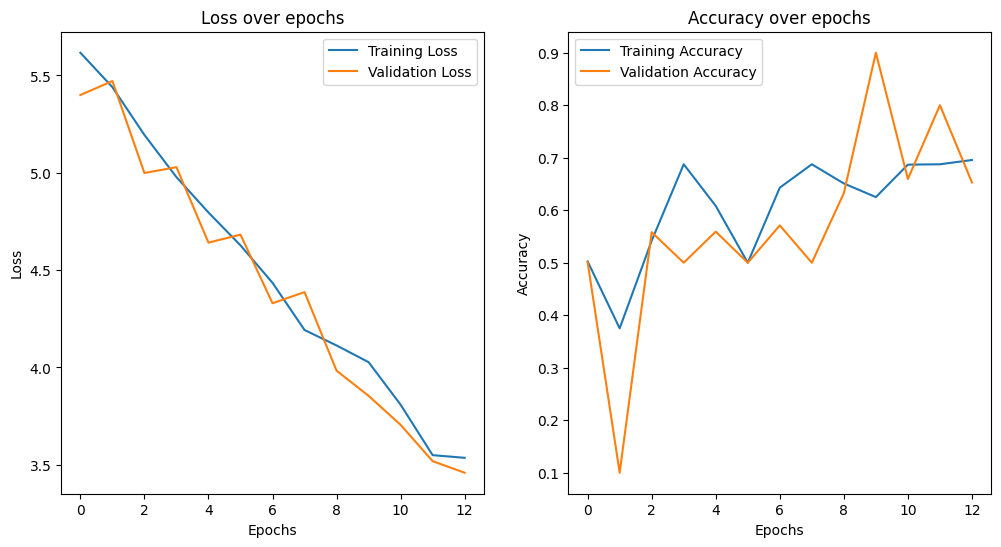

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'VGG16',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: VGG16, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model VGG16, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **inceptionv3**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5980603694915771
Model: InceptionV3, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.545258641242981
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.6142241358757019
Model: InceptionV3, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.548491358757019
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.6088362336158752
Model: InceptionV3, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5721982717514038
Model: InceptionV3, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.579741358757019
Model: InceptionV3, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5538793206214905
Model: InceptionV3, Activation: tanh, Dropout R

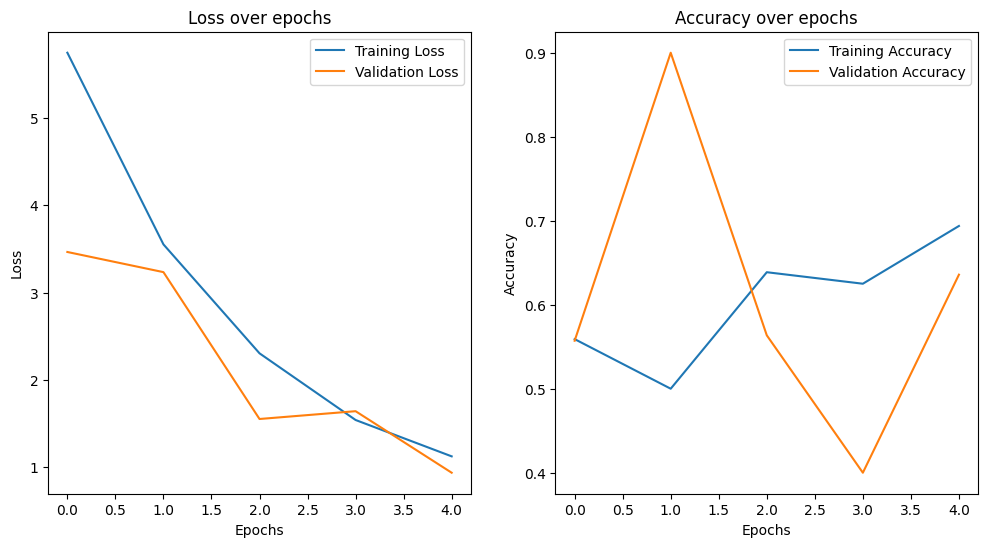

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-30:]:  # Fine-tune the last 30 layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'InceptionV3',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: InceptionV3, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model InceptionV3, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **Nasnetmobile**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'NASNetMobile',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: NASNetMobile, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model NASNetMobile, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.20000000298023224
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.4000000059604645
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: NASNetMobile, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5161637663841248
Model: NASNetMobile, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: NASNetMobile, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.20000000298023224
Model: NASNetMobile, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Ac

# **Vgg19**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG19, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5635775923728943
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG19, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.6066810488700867
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG19, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.6034482717514038
Model: VGG19, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5161637663841248
Model: VGG19, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.4000000059604645
Model: VGG19, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accurac

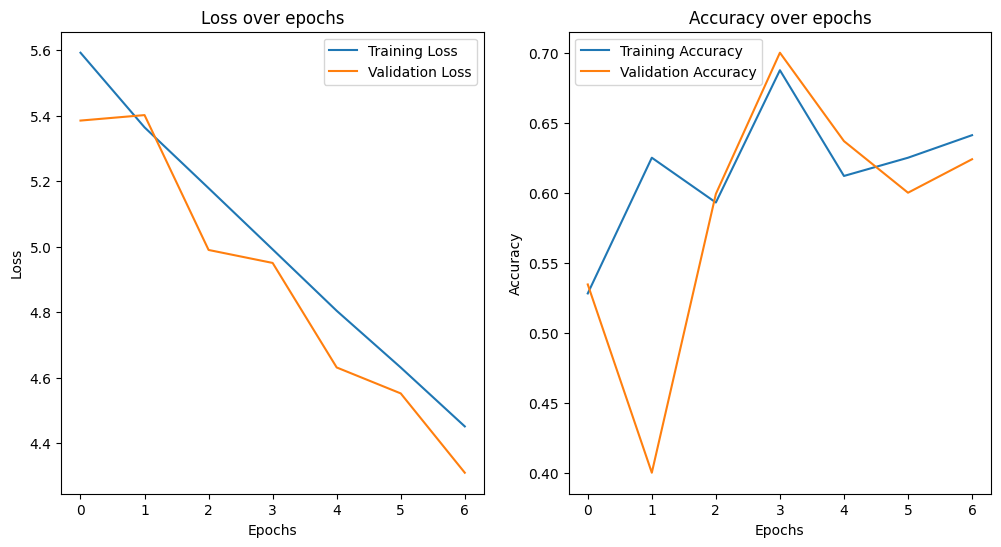

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-4:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'VGG19',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: VGG19, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model VGG19, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **EFficentb0**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.4881465435028076
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.537715494632721
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: EfficientNetB0, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.51293

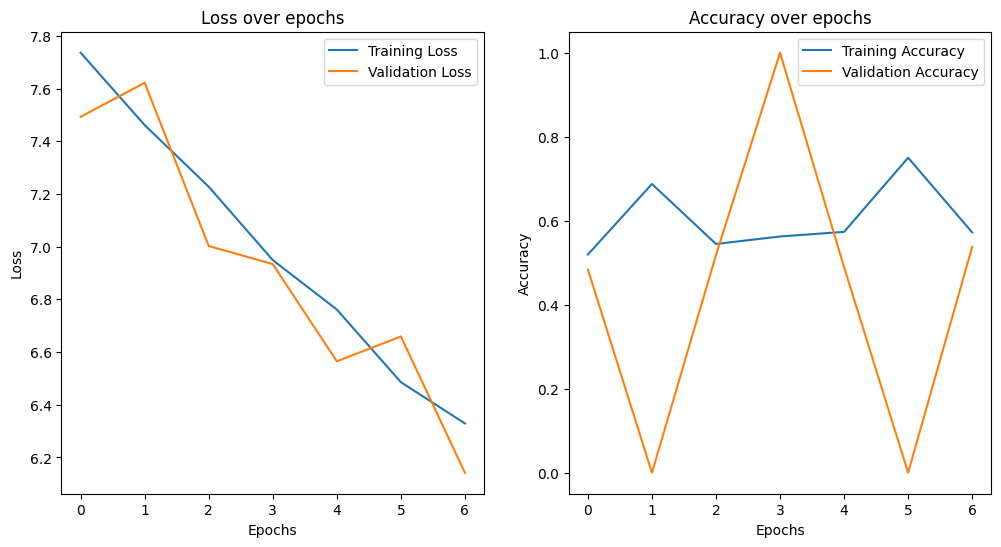

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'EfficientNetB0',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: EfficientNetB0, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model EfficientNetB0, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# **densenet169**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'DenseNet169',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: DenseNet169, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model DenseNet169, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.6799569129943848
Model: DenseNet169, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.576508641242981
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.610991358757019
Model: DenseNet169, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.0
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.20000000298023224
Model: DenseNet169, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.5915948152542114
Model: DenseNet169, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0


# **Mobilev2**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3758 images belonging to 2 classes.
Found 938 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.5334051847457886
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.5290948152542114
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.1, Learning Rate: 1e-05, Validation Accuracy: 0.5150862336158752
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: MobileNetV2, Activation: relu, Dropout Rate: 0.2, Learning Rate: 1e-05, Validation Accuracy: 0.4924568831920624
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 0.0001, Validation Accuracy: 0.0
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.0, Learning Rate: 1e-05, Validation Accuracy: 0.48383620381355286
Model: MobileNetV2, Activation: tanh, Dropout Rate: 0.1, Learning Rate: 0.0001, Validati

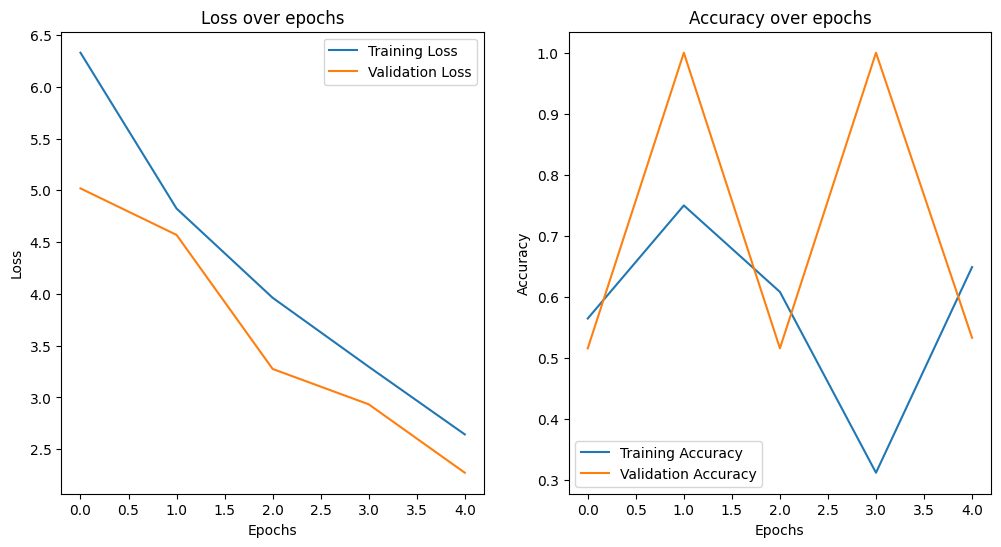

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import precision_recall_fscore_support
import json

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Data paths
data_dir = '/content/drive/My Drive/4o insan gpt /ssler-20240820T074747Z-001/ssler/high_ss'
img_height = 224
img_width = 224
batch_size = 16

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Data generators without augmentation
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    validation_split=0.2
)

# Data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['ham', 'v2']
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['ham', 'v2']
)

# Model creation function for MobileNetV2
def create_model(activation='relu', dropout_rate=0.0, learning_rate=1e-4):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    for layer in base_model.layers[-10:]:  # Fine-tune the last few layers
        layer.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation=activation, kernel_regularizer=l2(0.01))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',  # Binary classification
                  metrics=['accuracy'])
    return model

# Hyperparameters
activations = ['relu', 'tanh', 'sigmoid']
dropout_rates = [0.0, 0.1, 0.2]
learning_rates = [1e-4, 1e-5]
epochs = 20
early_stopping_patience = 3  # Early stopping patience

best_accuracy = 0
best_params = {}
all_results = []

results_file = 'training_results.json'
if os.path.exists(results_file):
    with open(results_file, 'r') as file:
        all_results = json.load(file)
else:
    all_results = []

for activation in activations:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            try:
                model = create_model(activation, dropout_rate, learning_rate)

                # Define callbacks
                early_stopping = tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=early_stopping_patience,
                    restore_best_weights=True
                )

                history = model.fit(
                    train_generator,
                    steps_per_epoch=train_generator.samples // train_generator.batch_size,
                    epochs=epochs,
                    validation_data=val_generator,
                    validation_steps=val_generator.samples // val_generator.batch_size,
                    callbacks=[early_stopping],
                    verbose=0
                )

                val_accuracy = history.history['val_accuracy'][-1]
                result = {
                    'model': 'MobileNetV2',
                    'activation': activation,
                    'dropout_rate': dropout_rate,
                    'learning_rate': learning_rate,
                    'val_accuracy': val_accuracy,
                    'history': history.history
                }
                all_results.append(result)

                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = result

                with open(results_file, 'w') as file:
                    json.dump(all_results, file)

                print(f"Model: MobileNetV2, Activation: {activation}, Dropout Rate: {dropout_rate}, Learning Rate: {learning_rate}, Validation Accuracy: {val_accuracy}")

            except Exception as e:
                print(f"Error with model MobileNetV2, activation {activation}, dropout {dropout_rate}, learning rate {learning_rate}: {e}")

print("\nEn iyi parametreler:", best_params)
print("En iyi skor:", best_accuracy)

# Train the best model
best_model = create_model(
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=early_stopping_patience,
    restore_best_weights=True
)

history = best_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping],
    verbose=0
)

# Predictions and evaluation metrics
predictions = best_model.predict(val_generator)
y_true = val_generator.classes
y_pred = (predictions > 0.5).astype(int).reshape(-1)

precision_weighted, recall_weighted, f1_score_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
precision_micro, recall_micro, f1_score_micro, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
precision_macro, recall_macro, f1_score_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
precision_none, recall_none, f1_score_none, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1 Score:", f1_score_weighted)
print("Micro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1 Score:", f1_score_micro)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_score_macro)
print("Precision (None):", precision_none)
print("Recall (None):", recall_none)
print("F1 Score (None):", f1_score_none)

# Plotting the results
history = best_params['history']
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
